# BetaGDD — PEP725 Apple (Global model)

Mirrors `beta_gdd_synthetic_recovery.ipynb` for PEP725 apple data.

1. Train `GlobalBetaGDDModel` on both apple cultivars and inspect learned parameters.
2. **Synthetic recovery test**: verify the optimizer recovers known ground-truth parameters.
3. **Profile loss** over α, β, and both threshold parameters to assess identifiability.

## Config

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm

from pysephone.constants import KEY_DATA_SOURCE, KEY_FEATURES, KEY_LOC_ID, KEY_YEAR
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.beta_gdd import GlobalBetaGDDModel
from pysephone.models.torch_base import BaseTorchModel

OBS_KEY = 'BBCH_60'
CUTOFF  = 2010
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## 1. Load data

In [2]:
cal    = Calendar(default_start='10-01', default_length=365)
_cache = FeatureCache.load(FeatureCache.default_path('PEP725_Apple', ['temperature_2m_mean']))
ds_all = Dataset.load('PEP725_Apple', calendar=cal, feature_providers=[_cache])

target_fn = lambda s: s['observations'][OBS_KEY]

years_trn = [y for y in ds_all.years if y < CUTOFF]
years_tst = [y for y in ds_all.years if y >= CUTOFF]
ds_trn = ds_all.select_years(years_trn)
ds_tst = ds_all.select_years(years_tst)

print(f'All:   {len(ds_all)} samples  ({min(ds_all.years)}–{max(ds_all.years)})')
print(f'Train: {len(ds_trn)} samples  ({min(years_trn)}–{max(years_trn)})')
print(f'Test:  {len(ds_tst)} samples  ({min(years_tst)}–{max(years_tst)})')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 36098.77it/s]


All:   6761 samples  (1986–2015)
Train: 5223 samples  (1986–2009)
Test:  1538 samples  (2010–2015)


## 2. Train GlobalBetaGDDModel

In [3]:
model, fit_info = GlobalBetaGDDModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model_kwargs     = dict(
        t_low            = 1.4,    # Utah model lower positive-chilling threshold
        t_high           = 15.9,   # Utah model upper positive-chilling threshold
        learn_bounds     = False,
        alpha_init       = 2.0,
        beta_init        = 2.0,
        learn_alpha_beta = True,
        learn_t_base     = False,
        t_base_init      = 5.0,
        learn_thresholds = True,
    ),
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device  = DEVICE,
    verbose = True,
)
print('Done.')

GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=1.58442: 100%|██████████| 8/8 [00:00<00:00, 32.95it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=1.47362: 100%|██████████| 8/8 [00:00<00:00, 139.58it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=1.31159: 100%|██████████| 8/8 [00:00<00:00, 104.90it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=1.19604: 100%|██████████| 8/8 [00:00<00:00, 139.74it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=1.06119: 100%|██████████| 8/8 [00:00<00:00, 142.35it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=0.96391: 100%|██████████| 8/8 [00:00<00:00, 143.54it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=0.86530: 100%|██████████| 8/8 [00:00<00:00, 135.82it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=0.80417: 100%|██████████| 8/8 [00:00<00:00, 102.75it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=0.70517: 100%|██████████| 8/8 [00:00<00:00, 97.38it/s]
Glo

Done.


## 3. Inspect learned parameters

In [4]:
α      = model.alpha.item()
β      = model.beta.item()
t_low  = model.t_low_eff.item()
t_hi   = model.t_high_eff.item()
t_opt  = t_low + (t_hi - t_low) * (α - 1) / (α + β - 2)
t_base = model._gdd._tb.item()

print(f'α       = {α:.3f}  (init 2.0)')
print(f'β       = {β:.3f}  (init 2.0)')
print(f't_low   = {t_low:.2f} °C')
print(f't_high  = {t_hi:.2f} °C')
print(f'T_opt   = {t_opt:.2f} °C')
print(f't_base  = {t_base:.2f} °C')

α       = 1.849  (init 2.0)
β       = 2.319  (init 2.0)
t_low   = 1.40 °C
t_high  = 15.90 °C
T_opt   = 7.08 °C
t_base  = 5.00 °C


In [5]:
res = SingleTargetRegression.run(
    model=model, dataset_train=ds_trn, dataset_test=ds_tst,
    target_fn=target_fn, run_name='GlobalBetaGDD',
)
m = res.compute_metrics()
for split in ('train', 'test'):
    mm = m[split]
    print(f"{split:5s}  RMSE={mm['rmse']:.2f}  MAE={mm['mae']:.2f}  R²={mm['r2']:.3f}")

train  RMSE=11.91  MAE=7.73  R²=-1.088
test   RMSE=8.85  MAE=6.02  R²=-0.098


## 4. Synthetic recovery test

Build a ground-truth model with known parameters (different from defaults), generate
synthetic bloom dates, then fit a fresh model to those dates.
Recovery ≈ ground truth validates the forward pass, loss, and optimizer.

In [6]:
GT = dict(
    alpha_init       = 3.0,
    beta_init        = 2.0,
    learn_alpha_beta = False,
    t_low            = -2.0,
    t_high           = 14.0,
    learn_bounds     = False,
    t_base_init      = 3.5,
    learn_t_base     = False,
    learn_thresholds = False,
)

gt_model = GlobalBetaGDDModel(**GT).to(DEVICE)
gt_model.eval()

dl = GlobalBetaGDDModel._make_dataloader(ds_trn, batch_size=512, shuffle=False)

synth_doys = {}
with torch.no_grad():
    for xs in dl:
        xs = BaseTorchModel._batch_to_device(xs, torch.device(DEVICE))
        pred_ix, _ = gt_model(xs)
        for src, loc_id, year, doy in zip(
            xs[KEY_DATA_SOURCE],
            xs[KEY_LOC_ID],
            xs[KEY_YEAR],
            pred_ix.cpu().tolist(),
        ):
            synth_doys[(src, loc_id, int(year))] = doy

print(f'Generated {len(synth_doys)} synthetic bloom dates.')
doys = list(synth_doys.values())
print(f'DOY range: {min(doys):.0f} – {max(doys):.0f},  mean {np.mean(doys):.1f}')

Generated 5223 synthetic bloom dates.
DOY range: 167 – 364,  mean 252.0


In [7]:
def synth_target_fn(sample):
    src    = sample[KEY_DATA_SOURCE]
    loc_id = sample[KEY_LOC_ID]
    year   = int(sample[KEY_YEAR])
    ix     = int(round(synth_doys[(src, loc_id, year)]))
    return np.datetime64(sample['season_start'], 'D') + np.timedelta64(ix, 'D')

rec_model, rec_fit = GlobalBetaGDDModel.fit(
    target_fn    = synth_target_fn,
    dataset      = ds_trn,
    model_kwargs = dict(
        t_low            = GT['t_low'],
        t_high           = GT['t_high'],
        learn_bounds     = False,
        alpha_init       = 2.0,
        beta_init        = 2.0,
        learn_alpha_beta = True,
        learn_t_base     = True,
        t_base_init      = 5.0,
        learn_thresholds = True,
    ),
    num_epochs               = 1000,
    batch_size               = 512,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-4,
    device  = DEVICE,
    verbose = True,
)
print('Done.')

GlobalBetaGDDModel epoch [    1/1000] lr=1.00e-03 loss=3.94869: 100%|██████████| 8/8 [00:00<00:00, 88.63it/s]
GlobalBetaGDDModel epoch [    2/1000] lr=1.00e-03 loss=3.65181: 100%|██████████| 8/8 [00:00<00:00, 120.85it/s]
GlobalBetaGDDModel epoch [    3/1000] lr=1.00e-03 loss=3.34035: 100%|██████████| 8/8 [00:00<00:00, 102.90it/s]
GlobalBetaGDDModel epoch [    4/1000] lr=1.00e-03 loss=2.99292: 100%|██████████| 8/8 [00:00<00:00, 130.04it/s]
GlobalBetaGDDModel epoch [    5/1000] lr=1.00e-03 loss=2.65760: 100%|██████████| 8/8 [00:00<00:00, 126.39it/s]
GlobalBetaGDDModel epoch [    6/1000] lr=1.00e-03 loss=2.22800: 100%|██████████| 8/8 [00:00<00:00, 126.61it/s]
GlobalBetaGDDModel epoch [    7/1000] lr=1.00e-03 loss=1.82334: 100%|██████████| 8/8 [00:00<00:00, 126.88it/s]
GlobalBetaGDDModel epoch [    8/1000] lr=1.00e-03 loss=1.46250: 100%|██████████| 8/8 [00:00<00:00, 128.15it/s]
GlobalBetaGDDModel epoch [    9/1000] lr=1.00e-03 loss=1.18099: 100%|██████████| 8/8 [00:00<00:00, 128.19it/s]
Gl

Done.


In [8]:
def _t_opt(alpha, beta, t_low, t_high):
    return t_low + (t_high - t_low) * (alpha - 1) / (alpha + beta - 2)

INIT    = dict(alpha=2.0, beta=2.0, t_low=GT['t_low'], t_high=GT['t_high'],
               T_opt=_t_opt(2.0, 2.0, GT['t_low'], GT['t_high']), t_base=5.0)
GT_vals = dict(alpha=GT['alpha_init'], beta=GT['beta_init'],
               t_low=GT['t_low'], t_high=GT['t_high'],
               T_opt=_t_opt(GT['alpha_init'], GT['beta_init'], GT['t_low'], GT['t_high']),
               t_base=GT['t_base_init'])
REC     = dict(alpha=rec_model.alpha.item(), beta=rec_model.beta.item(),
               t_low=rec_model.t_low_eff.item(), t_high=rec_model.t_high_eff.item(),
               T_opt=_t_opt(rec_model.alpha.item(), rec_model.beta.item(),
                            rec_model.t_low_eff.item(), rec_model.t_high_eff.item()),
               t_base=rec_model._gdd._tb.item())

df_cmp = pd.DataFrame({'init': INIT, 'ground_truth': GT_vals, 'recovered': REC}).round(3)
df_cmp['error'] = (df_cmp['recovered'] - df_cmp['ground_truth']).round(3)
print(df_cmp.to_string())

        init  ground_truth  recovered  error
alpha    2.0         3.000      2.933 -0.067
beta     2.0         2.000      1.956 -0.044
t_low   -2.0        -2.000     -2.000  0.000
t_high  14.0        14.000     14.000  0.000
T_opt    6.0         8.667      8.706  0.039
t_base   5.0         3.500      3.929  0.429


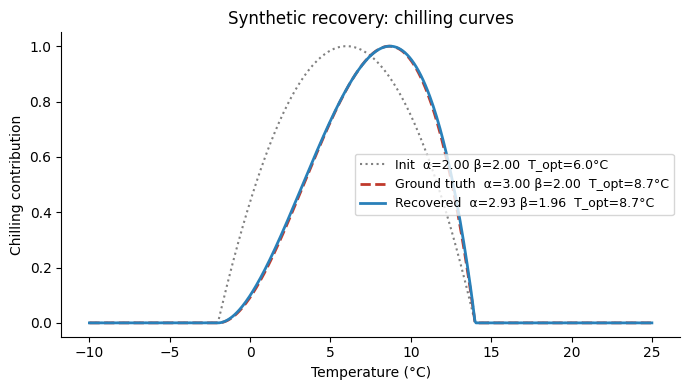

In [ ]:
T_GRID = np.linspace(-10, 25, 500)
eps = 1e-6

def beta_curve(alpha, beta, t_low, t_high, T):
    T_norm = np.clip((T - t_low) / (t_high - t_low + eps), eps, 1 - eps)
    lc = (alpha - 1) * np.log(T_norm) + (beta - 1) * np.log(1 - T_norm)
    mode = np.clip((alpha - 1) / (alpha + beta - 2), eps, 1 - eps)
    lm = (alpha - 1) * np.log(mode) + (beta - 1) * np.log(1 - mode)
    return np.where((T >= t_low) & (T <= t_high), np.exp(lc - lm), 0.0)

fig, ax = plt.subplots(figsize=(7, 4))
for label, vals, color, ls, lw in [
    ('Init',         INIT,    'grey',    ':',  1.5),
    ('Ground truth', GT_vals, '#c0392b', '--', 2.0),
    ('Recovered',    REC,     '#2980b9', '-',  2.0),
]:
    curve = beta_curve(vals['alpha'], vals['beta'], vals['t_low'], vals['t_high'], T_GRID)
    ax.plot(T_GRID, curve, color=color, ls=ls, lw=lw,
            label=f'{label}  α={vals["alpha"]:.2f} β={vals["beta"]:.2f}  T_opt={vals["T_opt"]:.1f}°C')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Chilling contribution')
ax.set_title('Synthetic recovery: chilling curves')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Profile loss over α and β

Fix one shape parameter to a grid of values, optimise all others to convergence,
record the minimum validation loss.  A clear dip = identifiable.  Flat = equifinality.

In [10]:
def _best_val_loss(fit_info):
    vals = [e['val']['loss'] for e in fit_info['epochs'] if 'val' in e]
    return min(vals) if vals else fit_info['epochs'][-1]['loss']

def profile_over(param, grid, ds, t_fn, device, num_epochs=500, patience=5):
    assert param in ('alpha', 'beta')
    losses = []
    for val in tqdm(grid, desc=f'Profile α' if param == 'alpha' else 'Profile β'):
        m = GlobalBetaGDDModel(
            alpha_init=float(val) if param == 'alpha' else 2.0,
            beta_init =float(val) if param == 'beta'  else 2.0,
            learn_alpha_beta=True,
            t_low=1.4, t_high=15.9, learn_bounds=False,
            learn_t_base=False, t_base_init=5.0, learn_thresholds=True,
        ).to(device)
        if param == 'alpha':
            m._raw_alpha.requires_grad_(False)
        else:
            m._raw_beta.requires_grad_(False)
        _, fi = GlobalBetaGDDModel.fit(
            target_fn=t_fn, dataset=ds, model=m,
            num_epochs=num_epochs, batch_size=512, val_period=5,
            optimizer='adam', optimizer_kwargs=dict(lr=1e-3, weight_decay=1e-4),
            early_stopping=True, early_stopping_patience=patience,
            early_stopping_min_delta=1e-4, device=device, verbose=False,
        )
        losses.append(_best_val_loss(fi))
    return losses

GRID = np.linspace(1.1, 6.0, 25)

alpha_losses = profile_over('alpha', GRID, ds_trn, target_fn, DEVICE)
beta_losses  = profile_over('beta',  GRID, ds_trn, target_fn, DEVICE)

Profile α:   0%|          | 0/25 [00:00<?, ?it/s]

Profile β:   0%|          | 0/25 [00:00<?, ?it/s]

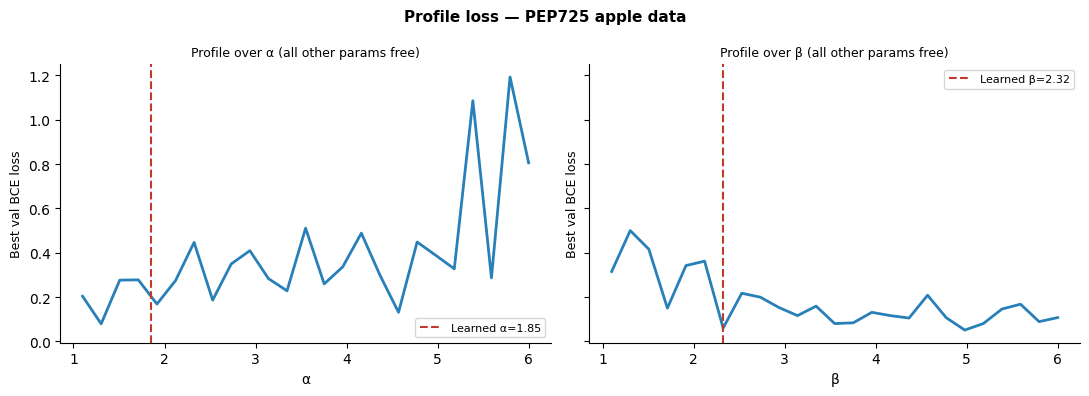

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle('Profile loss — PEP725 apple data', fontsize=11, fontweight='bold')

for ax, losses, param, learned_val in [
    (axes[0], alpha_losses, 'α', model.alpha.item()),
    (axes[1], beta_losses,  'β', model.beta.item()),
]:
    ax.plot(GRID, losses, color='#2980b9', lw=2)
    ax.axvline(learned_val, color='#c0392b', lw=1.5, ls='--',
               label=f'Learned {param}={learned_val:.2f}')
    ax.set_xlabel(param, fontsize=10)
    ax.set_ylabel('Best val BCE loss', fontsize=9)
    ax.set_title(f'Profile over {param} (all other params free)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Quantitative identifiability metrics

- **Curvature at minimum** — second derivative at argmin (finite differences). Higher = better identified.
- **Profile CI width** — width of `{θ : L(θ) ≤ L_min + δ}`. Narrower = tighter constraint.

In [12]:
def identifiability_metrics(grid, losses, delta=0.005):
    grid   = np.asarray(grid,   dtype=float)
    losses = np.asarray(losses, dtype=float)
    i_min    = np.argmin(losses)
    min_loss = losses[i_min]
    argmin   = grid[i_min]
    if 0 < i_min < len(grid) - 1:
        h  = grid[i_min + 1] - grid[i_min - 1]
        d2 = (losses[i_min + 1] - 2 * losses[i_min] + losses[i_min - 1]) / (h / 2) ** 2
    else:
        d2 = float('nan')
    in_ci = losses <= min_loss + delta
    lo, hi = i_min, i_min
    while lo > 0 and in_ci[lo - 1]:
        lo -= 1
    while hi < len(grid) - 1 and in_ci[hi + 1]:
        hi += 1
    return dict(argmin=argmin, min_loss=min_loss, curvature=d2,
                ci_lo=grid[lo], ci_hi=grid[hi], ci_width=grid[hi] - grid[lo])


DELTA = 0.005

rows = {}
for param, losses_arr in [('α', alpha_losses), ('β', beta_losses)]:
    rows[param] = identifiability_metrics(GRID, losses_arr, delta=DELTA)

df_id = pd.DataFrame(rows).T[['argmin', 'min_loss', 'curvature', 'ci_lo', 'ci_hi', 'ci_width']].round(4)
df_id.index.name = 'param'
print(f'Profile identifiability metrics  (CI threshold δ={DELTA})')
print(df_id.to_string())

Profile identifiability metrics  (CI threshold δ=0.005)
       argmin  min_loss  curvature   ci_lo   ci_hi  ci_width
param                                                       
α      1.3042    0.0797     7.7053  1.3042  1.3042       0.0
β      4.9792    0.0514     2.0489  4.9792  4.9792       0.0


## 6. Profile loss over threshold parameters

In [13]:
def profile_over_threshold(which, grid_norm, ds, t_fn, device, num_epochs=500, patience=5):
    assert which in ('chilling', 'gdd')
    losses = []
    for val in tqdm(grid_norm,
                    desc='Profile chilling threshold' if which == 'chilling'
                         else 'Profile GDD threshold'):
        m = GlobalBetaGDDModel(
            alpha_init=2.0, beta_init=2.0, learn_alpha_beta=True,
            t_low=1.4, t_high=15.9, learn_bounds=False,
            learn_t_base=False, t_base_init=5.0, learn_thresholds=True,
        ).to(device)
        if which == 'chilling':
            m._tt_unit_threshold._threshold.data.fill_(float(val))
            m._tt_unit_threshold._threshold.requires_grad_(False)
        else:
            m._gdd_threshold._threshold.data.fill_(float(val))
            m._gdd_threshold._threshold.requires_grad_(False)
        _, fi = GlobalBetaGDDModel.fit(
            target_fn=t_fn, dataset=ds, model=m,
            num_epochs=num_epochs, batch_size=512, val_period=5,
            optimizer='adam', optimizer_kwargs=dict(lr=1e-3, weight_decay=1e-4),
            early_stopping=True, early_stopping_patience=patience,
            early_stopping_min_delta=1e-4, device=device, verbose=False,
        )
        losses.append(_best_val_loss(fi))
    return losses

THRESH_GRID = np.linspace(0.05, 0.95, 25)

chill_losses = profile_over_threshold('chilling', THRESH_GRID, ds_trn, target_fn, DEVICE)
gdd_losses   = profile_over_threshold('gdd',      THRESH_GRID, ds_trn, target_fn, DEVICE)

Profile chilling threshold:   0%|          | 0/25 [00:00<?, ?it/s]

Profile GDD threshold:   0%|          | 0/25 [00:00<?, ?it/s]

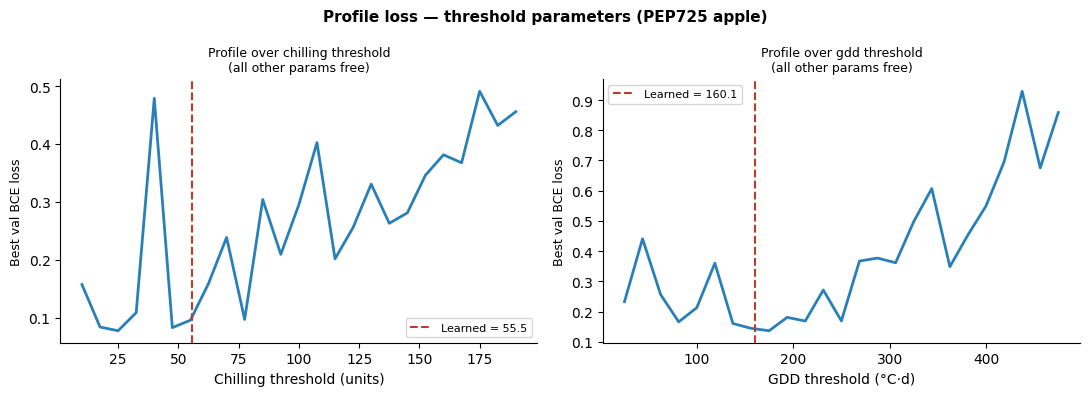


Profile identifiability metrics  (CI threshold δ=0.005)
              argmin  min_loss  curvature  ci_lo  ci_hi  ci_width
param                                                            
chill_thresh    25.0    0.0773     0.0007   25.0   25.0       0.0
gdd_thresh     175.0    0.1364     0.0001  175.0  175.0       0.0


In [14]:
chill_grid_phys = THRESH_GRID * 200.0
gdd_grid_phys   = THRESH_GRID * 500.0

learned_chill = model._tt_unit_threshold.threshold.item() * 200.0
learned_gdd   = model._gdd_threshold.threshold.item()     * 500.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig.suptitle('Profile loss — threshold parameters (PEP725 apple)',
             fontsize=11, fontweight='bold')

for ax, losses, phys_grid, learned_val, xlabel in [
    (axes[0], chill_losses, chill_grid_phys, learned_chill, 'Chilling threshold (units)'),
    (axes[1], gdd_losses,   gdd_grid_phys,   learned_gdd,   'GDD threshold (°C·d)'),
]:
    ax.plot(phys_grid, losses, color='#2980b9', lw=2)
    ax.axvline(learned_val, color='#c0392b', lw=1.5, ls='--',
               label=f'Learned = {learned_val:.1f}')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Best val BCE loss', fontsize=9)
    ax.set_title(f'Profile over {xlabel.split()[0].lower()} threshold\n(all other params free)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nProfile identifiability metrics  (CI threshold δ={DELTA})')
rows_thresh = {}
for label, losses, phys_grid in [
    ('chill_thresh', chill_losses, chill_grid_phys),
    ('gdd_thresh',   gdd_losses,   gdd_grid_phys),
]:
    rows_thresh[label] = identifiability_metrics(phys_grid, losses, delta=DELTA)

df_thresh = pd.DataFrame(rows_thresh).T[
    ['argmin', 'min_loss', 'curvature', 'ci_lo', 'ci_hi', 'ci_width']
].round(4)
df_thresh.index.name = 'param'
print(df_thresh.to_string())